# SaaS metrics: MRR, churn, cohorts and unit economics

A subscription business lives or dies on a few numbers: how much recurring
revenue it has, how fast that revenue leaks away, and whether each customer
is worth more than it cost to win them. This notebook builds each of those
from raw billing data, the way a BI analyst would:

1. Monthly recurring revenue (MRR) and where its growth comes from
2. Customer churn vs. revenue churn
3. Cohort retention: the single most useful SaaS chart
4. Unit economics by acquisition channel: LTV, CAC, payback

The data is a simulated B2B company (see `sample_data.py`). One thing is
planted for us to find: customers from paid search churn about twice as fast
as organic ones.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sample_data import saas_subscriptions

plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False})
customers, revenue = saas_subscriptions()

print(f"{len(customers):,} customers, {len(revenue):,} customer-months of billing")
customers.head()

4,376 customers, 34,192 customer-months of billing


,customer_id,signup_month,channel,acquisition_cost,churn_month,starting_plan
0,1,2023-01,Paid search,572.06,2023-10,Basic
1,2,2023-01,Organic,146.96,2023-06,Basic
2,3,2023-01,Partner,344.22,NaT,Basic
3,4,2023-01,Paid search,659.26,2023-06,Basic
4,5,2023-01,Paid search,1016.68,2023-02,Pro


In [ ]:
revenue.head()

,customer_id,month,plan,mrr
0,1,2023-01,Basic,29
1,1,2023-02,Pro,99
2,1,2023-03,Pro,99
3,1,2023-04,Pro,99
4,1,2023-05,Pro,99


Two tables, as you'd get from most billing systems: one row per customer, and
one row per customer per month they paid. Everything below comes from these.

## 1. MRR and its movements

MRR is the sum of every active subscription's monthly price. On its own it
hides a lot, so analysts break each month's change into **movements**:

- **New:** revenue from customers in their first month
- **Expansion:** existing customers paying more (upgrades)
- **Churned:** revenue lost from customers who left

MRR grew from $6,437 to $367,391 over 30 months
In the last 6 months, churn wiped out 52% of the MRR that new customers added


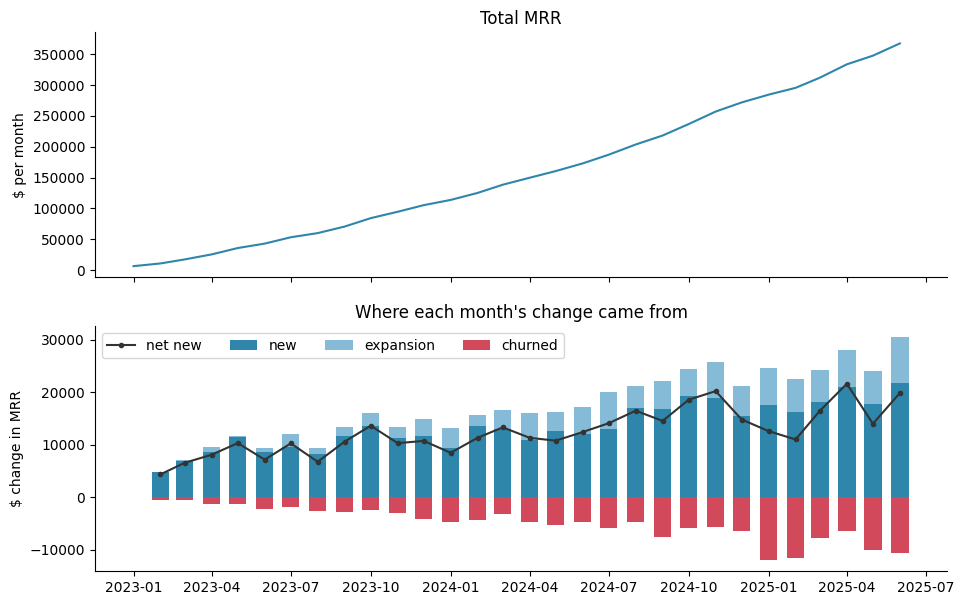

In [ ]:
mrr = revenue.pivot_table(index="customer_id", columns="month", values="mrr", aggfunc="sum").fillna(0)
months = mrr.columns

movements = []
for prev, cur in zip(months[:-1], months[1:], strict=True):
    before, after = mrr[prev], mrr[cur]
    movements.append({
        "month": cur,
        "new": after[(before == 0) & (after > 0)].sum(),
        "expansion": (after - before)[(before > 0) & (after > before)].sum(),
        "churned": -before[(before > 0) & (after == 0)].sum(),
    })
movements = pd.DataFrame(movements).set_index("month")
movements["net_new"] = movements.sum(axis=1)

total = mrr.sum()
print(f"MRR grew from ${total.iloc[0]:,.0f} to ${total.iloc[-1]:,.0f} over {len(months)} months")
print(f"In the last 6 months, churn wiped out {-movements.churned[-6:].sum() / movements.new[-6:].sum():.0%} "
      "of the MRR that new customers added")

fig, (top, bottom) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
top.plot(total.index.to_timestamp(), total.values, color="#2e86ab")
top.set(title="Total MRR", ylabel="$ per month")
x = movements.index.to_timestamp()
bottom.bar(x, movements.new, width=20, color="#2e86ab", label="new")
bottom.bar(x, movements.expansion, width=20, bottom=movements.new, color="#86bbd8", label="expansion")
bottom.bar(x, movements.churned, width=20, color="#d1495b", label="churned")
bottom.plot(x, movements.net_new, color="#333", marker="o", markersize=3, label="net new")
bottom.set(title="Where each month's change came from", ylabel="$ change in MRR")
bottom.legend(ncol=4);

The top chart looks like healthy growth. The bottom one shows the cost: the
red bars keep growing, because a bigger customer base means more people
leaving. A business that grows sign-ups but not retention eventually hits a
ceiling where churn cancels out new sales.

## 2. Customer churn vs. revenue churn

**Customer churn** counts logos lost. **Revenue churn** counts dollars. They
differ when big and small customers churn at different rates, and the gap
tells you which customers you're losing.

**Net revenue retention (NRR)** adds expansion back in: of the revenue you
had from existing customers a year ago, how much do you have now? Above 100%
means existing customers grow faster than they leave, which is what the best
SaaS companies achieve.

In [ ]:
was_active = (mrr[months[:-1]] > 0).to_numpy()
now_active = (mrr[months[1:]] > 0).to_numpy()
cust_churn = pd.Series((was_active & ~now_active).sum(axis=0) / was_active.sum(axis=0), index=months[1:])
rev_churn = -movements.churned / total.shift(1).loc[movements.index]

base_month, later_month = months[-13], months[-1]
base_customers = mrr.index[mrr[base_month] > 0]
nrr = mrr.loc[base_customers, later_month].sum() / mrr.loc[base_customers, base_month].sum()

print(f"Average monthly customer churn (last 12 months): {cust_churn[-12:].mean():.1%}")
print(f"Average monthly revenue churn (last 12 months):  {rev_churn[-12:].mean():.1%}")
print(f"Net revenue retention, {base_month} -> {later_month}: {nrr:.0%}")

Average monthly customer churn (last 12 months): 5.7%
Average monthly revenue churn (last 12 months):  3.0%
Net revenue retention, 2024-06 -> 2025-06: 102%


Revenue churn is about half of customer churn, which means the customers
who leave are mostly small ones (Basic plan), while big accounts stay. NRR
is just over 100%: upgrades from existing customers slightly more than make
up for the revenue lost to churn. That's healthy, but the margin is thin, so
a small rise in churn would tip it below 100%.

## 3. Cohort retention

Averages blend customers who joined two years ago with customers who joined
last month. A **cohort table** separates them: each row is the group that
signed up in one month, and each column is how many of them are still paying
N months later. It answers the questions an average can't: is retention
improving for newer customers? When do people leave?

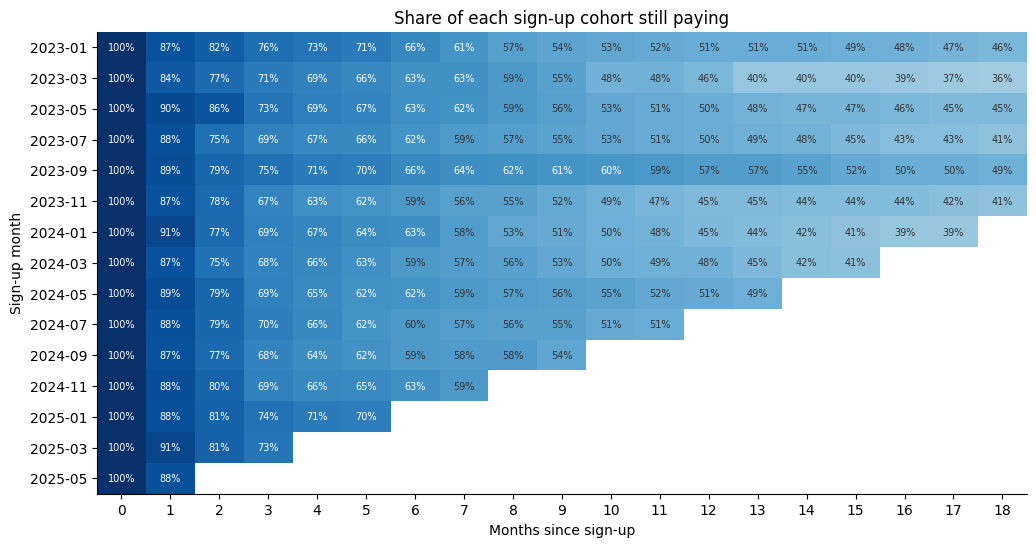

In [ ]:
first_month = revenue.groupby("customer_id").month.min()
rev = revenue.assign(cohort=revenue.customer_id.map(first_month))
rev["months_since"] = (rev.month - rev.cohort).apply(lambda d: d.n)

cohort_counts = rev.pivot_table(index="cohort", columns="months_since", values="customer_id", aggfunc="nunique")
retention = cohort_counts.div(cohort_counts[0], axis=0)

shown = retention.iloc[::2, :19]  # every other cohort, first 18 months, to keep it readable
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(shown.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(shown.shape[1]), shown.columns)
ax.set_yticks(range(len(shown)), shown.index.astype(str))
for i in range(shown.shape[0]):
    for j in range(shown.shape[1]):
        v = shown.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=7, color="white" if v > 0.6 else "#333")
ax.set(title="Share of each sign-up cohort still paying", xlabel="Months since sign-up", ylabel="Sign-up month");

In [ ]:
curve = retention.mean()
print("Average retention after:")
for m in [1, 3, 6, 12, 18]:
    print(f"  {m:>2} months: {curve[m]:.0%}")
print(f"Customers lost in the first 3 months: {1 - curve[3]:.0%}; "
      f"lost in the following 9 months: {curve[3] - curve[12]:.0%}")

Average retention after:
   1 months: 88%
   3 months: 70%
   6 months: 61%
  12 months: 49%
  18 months: 41%
Customers lost in the first 3 months: 30%; lost in the following 9 months: 21%


Read the table across a row to follow one cohort through time, and down a
column to compare cohorts at the same age. Here the colour fades fastest in
the first three months, then the decline slows. That's typical: customers who
never got value from the product leave early. It's also where to focus. A
better onboarding that saves even a few of those early losses compounds
through every later month.

## 4. Unit economics by channel

The question every growth team must answer: **is a customer worth more than
it costs to acquire them?**

- **CAC** (customer acquisition cost): what we spent to win one customer.
- **LTV** (lifetime value): monthly revenue × gross margin ÷ monthly churn
  rate. Dividing by churn turns "per month" into "per lifetime" (2% churn
  means an average lifetime of 50 months).
- **LTV:CAC**: above 3 is the common rule of thumb for healthy growth.
- **Payback**: months of gross profit needed to earn back the CAC.

We assume an 80% gross margin, which is typical for SaaS.

In [ ]:
GROSS_MARGIN = 0.80
months_billed = revenue.groupby("customer_id").size()
mean_mrr = revenue.groupby("customer_id").mrr.mean()

c = customers.assign(months_billed=customers.customer_id.map(months_billed),
                     mean_mrr=customers.customer_id.map(mean_mrr),
                     churned=customers.churn_month.notna())

econ = c.groupby("channel").agg(customers=("customer_id", "size"), cac=("acquisition_cost", "mean"),
                                arpa=("mean_mrr", "mean"), churned=("churned", "sum"),
                                months=("months_billed", "sum"))
econ["monthly_churn"] = econ.churned / econ.months
econ["ltv"] = econ.arpa * GROSS_MARGIN / econ.monthly_churn
econ["ltv_to_cac"] = econ.ltv / econ.cac
econ["payback_months"] = econ.cac / (econ.arpa * GROSS_MARGIN)

print(econ[["customers", "monthly_churn", "arpa", "cac", "ltv", "ltv_to_cac", "payback_months"]]
      .round({"monthly_churn": 3, "arpa": 0, "cac": 0, "ltv": 0, "ltv_to_cac": 1, "payback_months": 1})
      .to_string())

             customers  monthly_churn   arpa    cac     ltv  ltv_to_cac  payback_months
channel                                                                                
Organic           1971          0.049  107.0  225.0  1757.0         7.8             2.6
Paid search       1514          0.100  101.0  979.0   807.0         0.8            12.2
Partner            891          0.039  107.0  582.0  2176.0         3.7             6.8


Organic      still paying after 12 months: 55%
Paid search  still paying after 12 months: 33%
Partner      still paying after 12 months: 63%


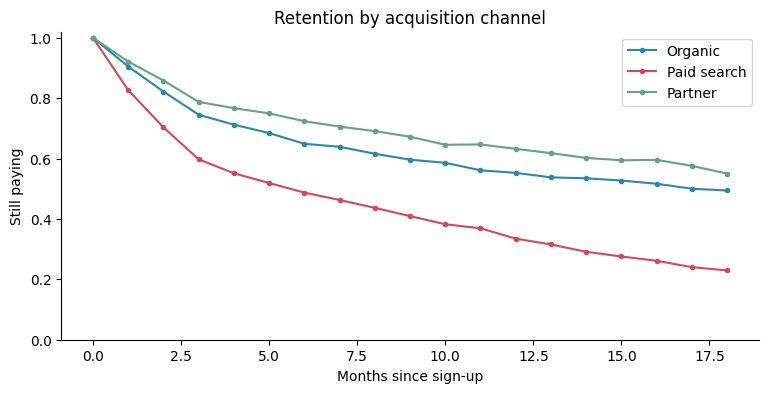

In [ ]:
def retention_curve(rows, max_age=18):
    """Share still paying at each age, counting only cohorts old enough to have reached it."""
    starters = rows[rows.months_since == 0]
    curve = {}
    for age in range(max_age + 1):
        old_enough = starters.customer_id[starters.cohort <= months[-1] - age]
        still_paying = rows[(rows.months_since == age) & rows.customer_id.isin(old_enough)]
        curve[age] = still_paying.customer_id.nunique() / len(old_enough)
    return pd.Series(curve)


fig, ax = plt.subplots(figsize=(9, 4))
for channel, color in zip(econ.index, ["#2e86ab", "#d1495b", "#66a182"], strict=True):
    ids = c.customer_id[c.channel == channel]
    curve = retention_curve(rev[rev.customer_id.isin(ids)])
    ax.plot(curve.index, curve.values, marker="o", markersize=3, color=color, label=channel)
    print(f"{channel:<12} still paying after 12 months: {curve[12]:.0%}")
ax.set(title="Retention by acquisition channel", xlabel="Months since sign-up", ylabel="Still paying", ylim=(0, 1.02))
ax.legend();

The planted effect shows up clearly. Paid search customers churn about twice
as fast as organic ones, and they also cost the most to acquire. That double
penalty is brutal: paid search's LTV:CAC is below 1, so **each customer it
brings in loses money**, and its payback period is longer than the average
customer stays. Organic is the most efficient channel, and partner customers
retain best of all.

This is a very common real-world finding: the easiest channel to scale
(paid ads) brings in customers who were the least sure they needed the
product. A sensible next step would be to look at *why* they leave (plan
fit, onboarding, expectations set by the ad) before cutting spend.

## Takeaways

- Break MRR change into new, expansion and churn. Total MRR alone hides leaks.
- Revenue churn below customer churn means you're mostly losing small customers.
- NRR above 100% is the mark of a product customers grow into.
- Cohort tables show *when* customers leave. Usually it's early, so fix onboarding first.
- Judge channels on LTV:CAC and payback, not on how many sign-ups they bring.